<a href="https://colab.research.google.com/github/BHall22/CIS3902-Data-Mining/blob/main/DataMining_Colab_GameSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

**Abstract:** This project analyzes Dec. 2016 Game Sales

**Student Name:** Bela Hall

# Imports

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz
from autoviz.AutoViz_Class import AutoViz_Class

# PyCaret
!pip install pycaret
from pycaret.classification import *

# Warnings
import warnings
warnings.filterwarnings('ignore')

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


# Input Data

In [ ]:
# Load Titanic dataset from seaborn (as sample input)
import seaborn as sns
#df = sns.load_dataset('titanic')
df = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')
#df.to_csv('titanic.csv', index=False)  # Save a local copy for AutoViz
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


# Explore Data

In [ ]:
# Summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [ ]:
# Statistical summary
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [ ]:
# Analysis of Nulls
df.isnull().sum()

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


Shape of your Data Set loaded: (16719, 16)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  9
    Number of Integer-Categorical Columns =  0
    Number of String-Categorical Columns =  4
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  1
    Number of NLP String Columns =  2
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    16 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
To fix these data quality issues in the dataset, import FixDQ from autoviz...
    All variab

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Name,object,0.011962,69,,,"2 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
Platform,object,0.000000,0,,,13 rare categories: Too many to list. Group them into a single category or drop the categories.
Year_of_Release,float64,1.608948,NA,1980.000000,2020.000000,"269 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 305 outliers greater than upper bound (2020.50) or lower than lower bound(1992.50). Cap them or remove them."
Genre,object,0.011962,0,,,"2 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
Publisher,object,0.322986,3,,,"54 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,, Possible high cardinality column with 581 unique values: Use hash encoding or text embedding to reduce dimension."
NA_Sales,float64,0.000000,NA,0.000000,41.360000,Column has 1687 outliers greater than upper bound (0.60) or lower than lower bound(-0.36). Cap them or remove them.
EU_Sales,float64,0.000000,NA,0.000000,28.960000,Column has 2061 outliers greater than upper bound (0.28) or lower than lower bound(-0.17). Cap them or remove them.
JP_Sales,float64,0.000000,NA,0.000000,10.220000,Column has 2434 outliers greater than upper bound (0.10) or lower than lower bound(-0.06). Cap them or remove them.
Other_Sales,float64,0.000000,NA,0.000000,10.570000,Column has 2243 outliers greater than upper bound (0.07) or lower than lower bound(-0.04). Cap them or remove them.
Global_Sales,float64,0.000000,NA,0.010000,82.530000,"Column has 1892 outliers greater than upper bound (1.08) or lower than lower bound(-0.55). Cap them or remove them., Column has a high correlation with ['NA_Sales', 'EU_Sales']. Consider dropping one of them."


Number of All Scatter Plots = 45


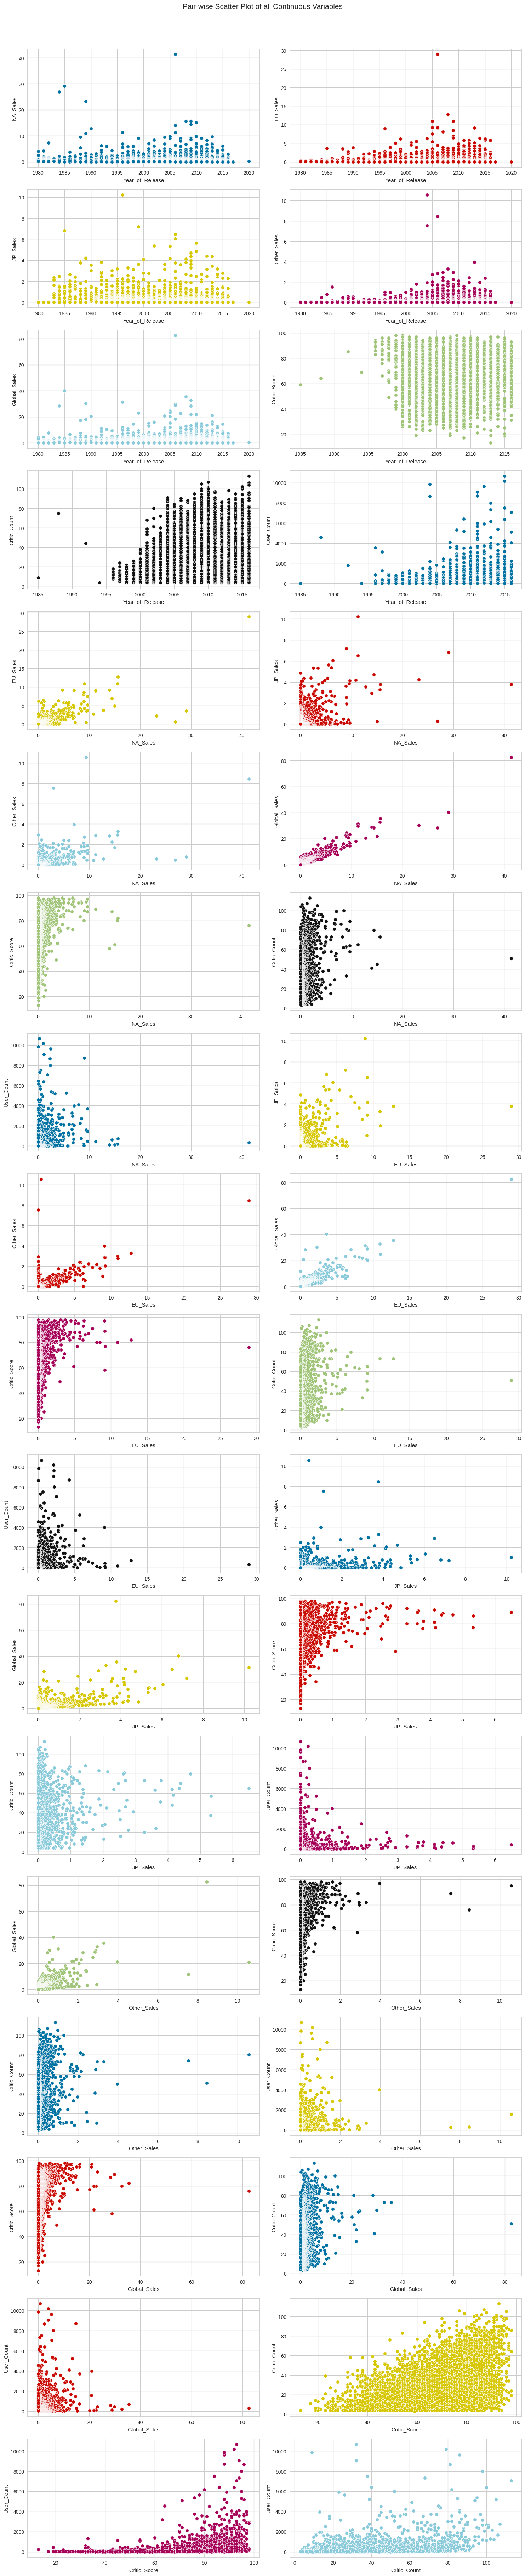

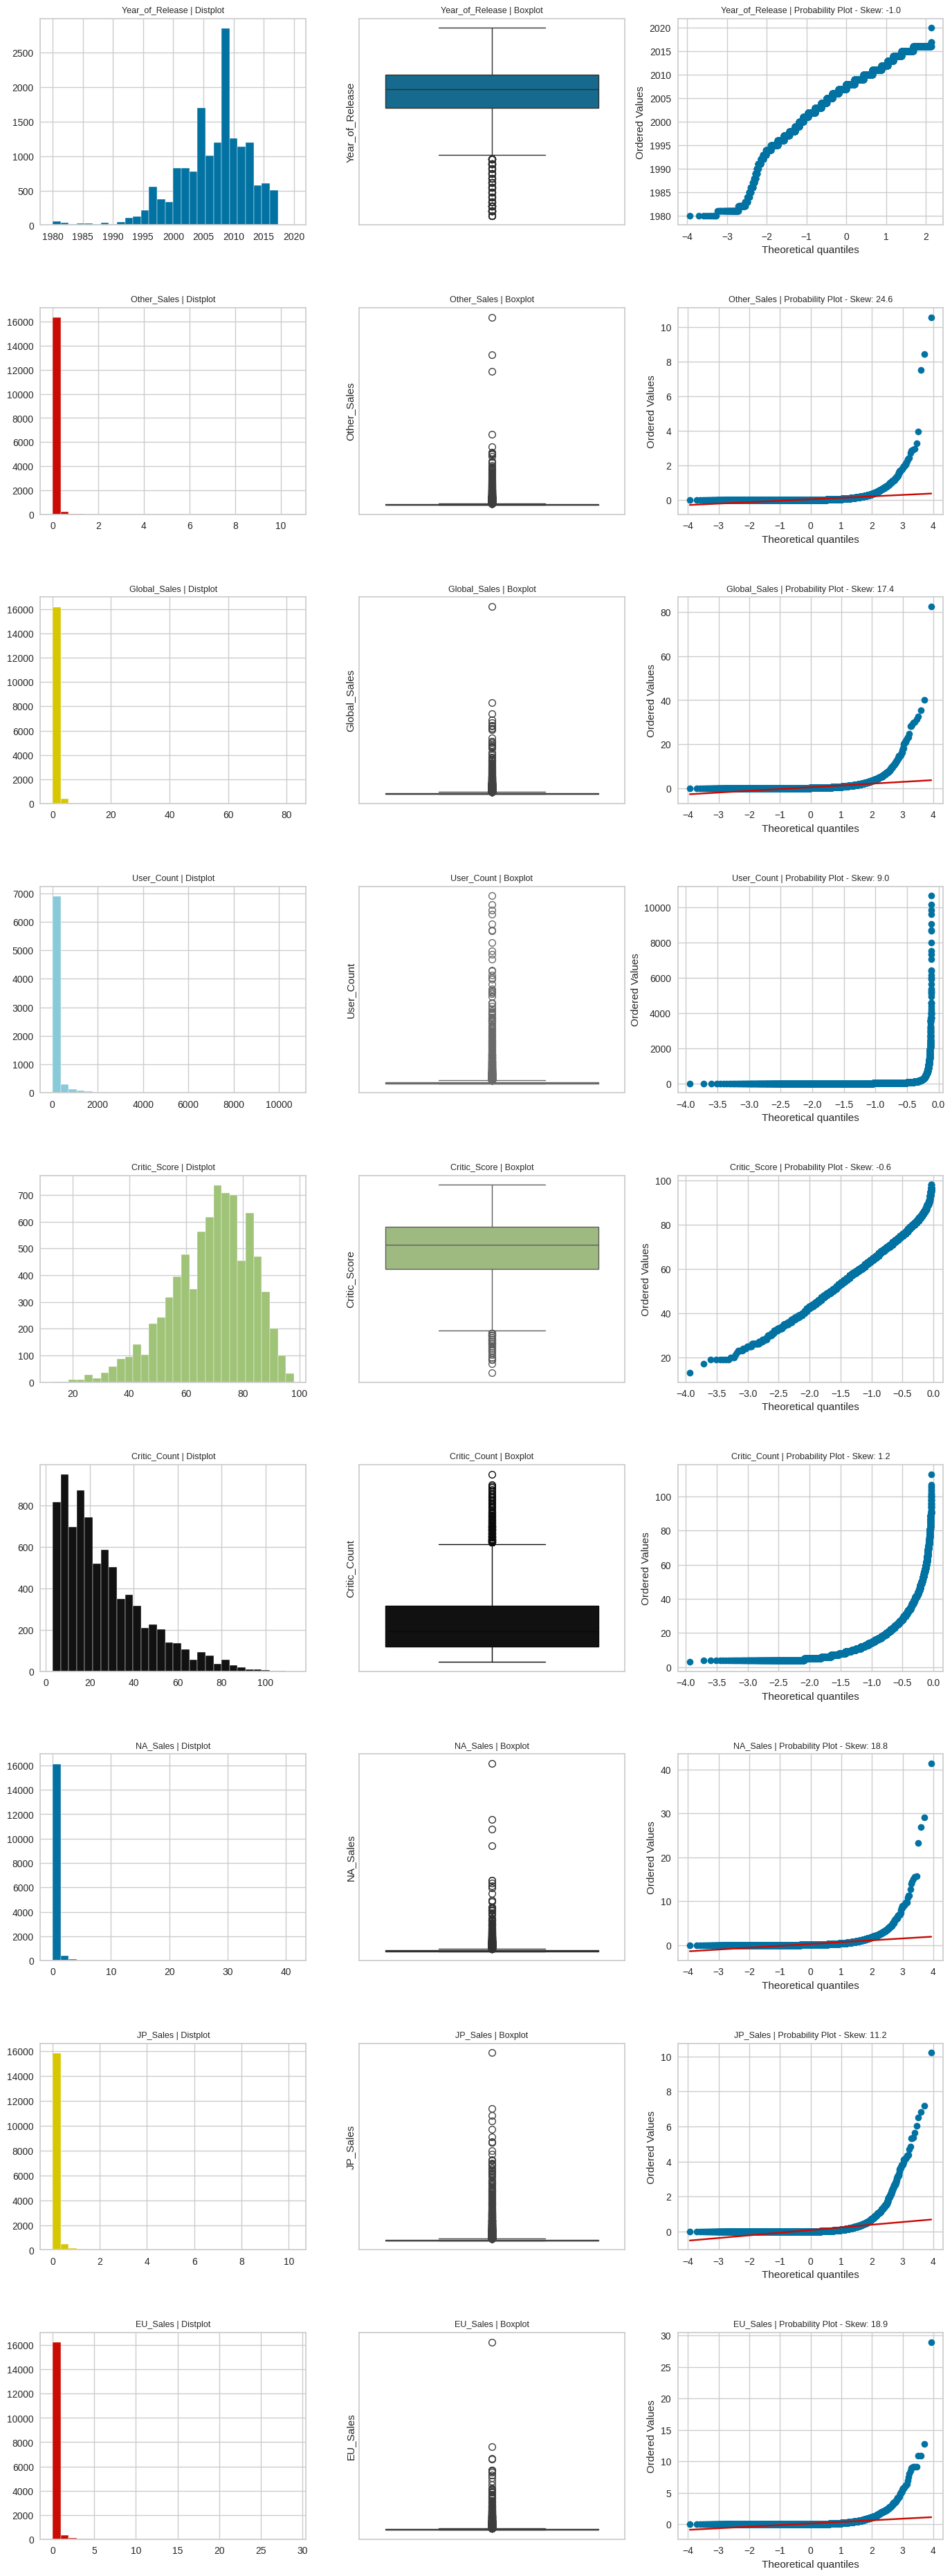

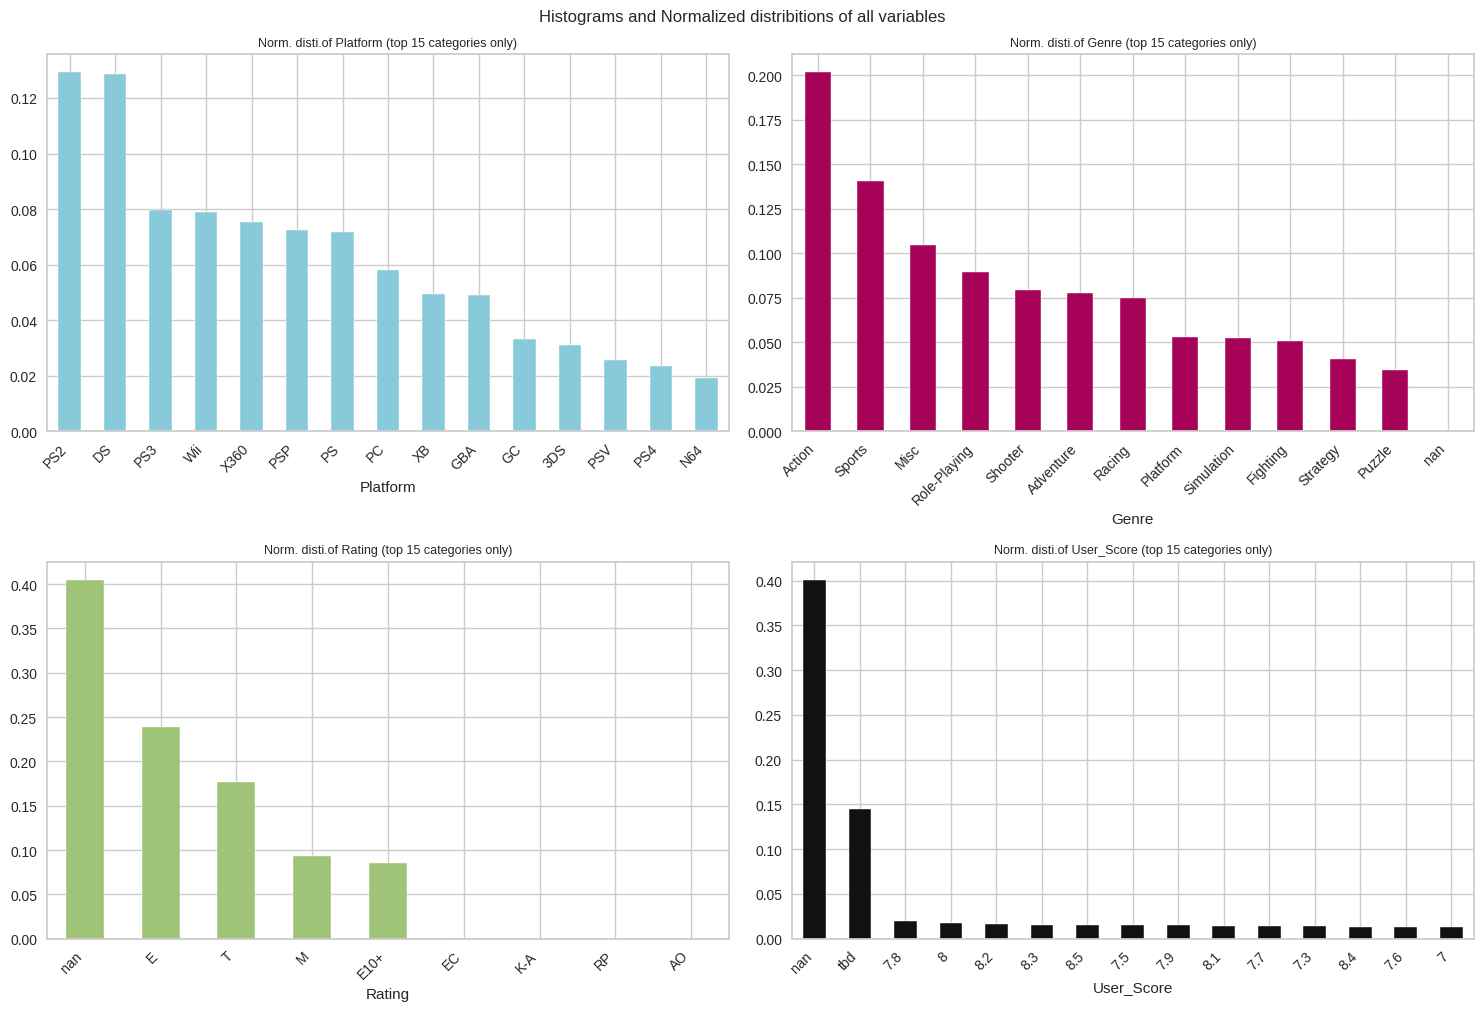

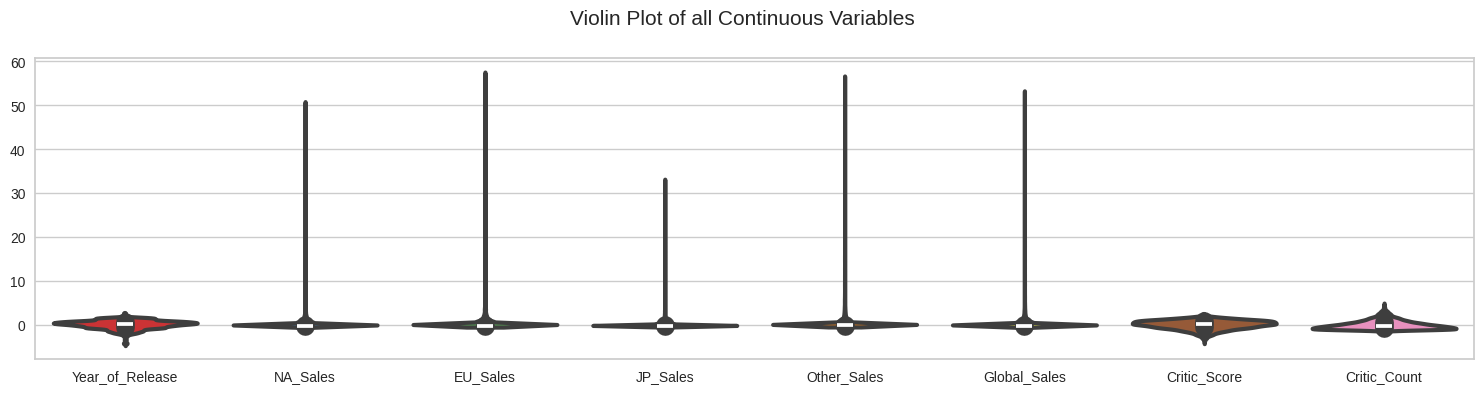

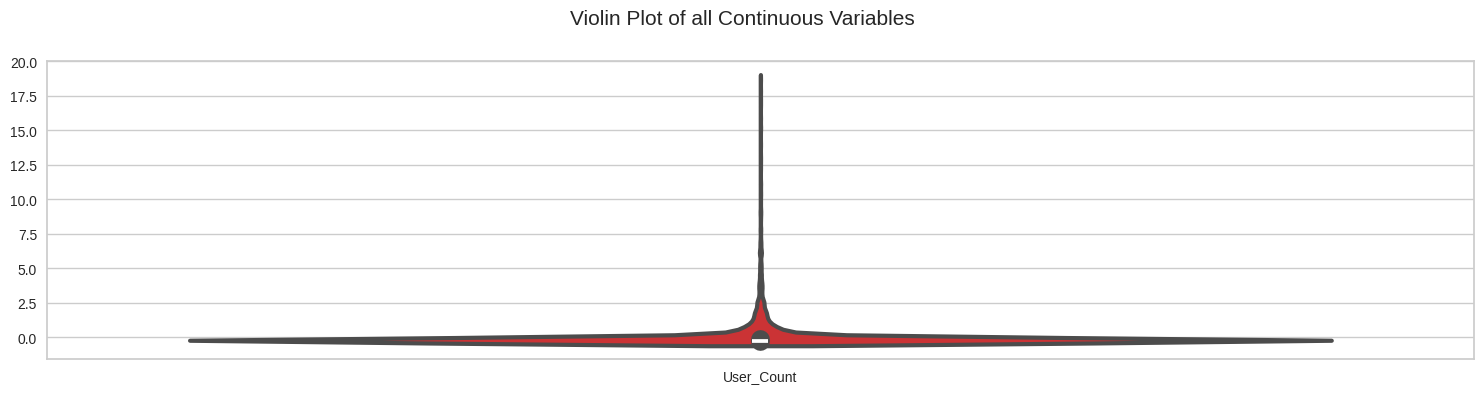

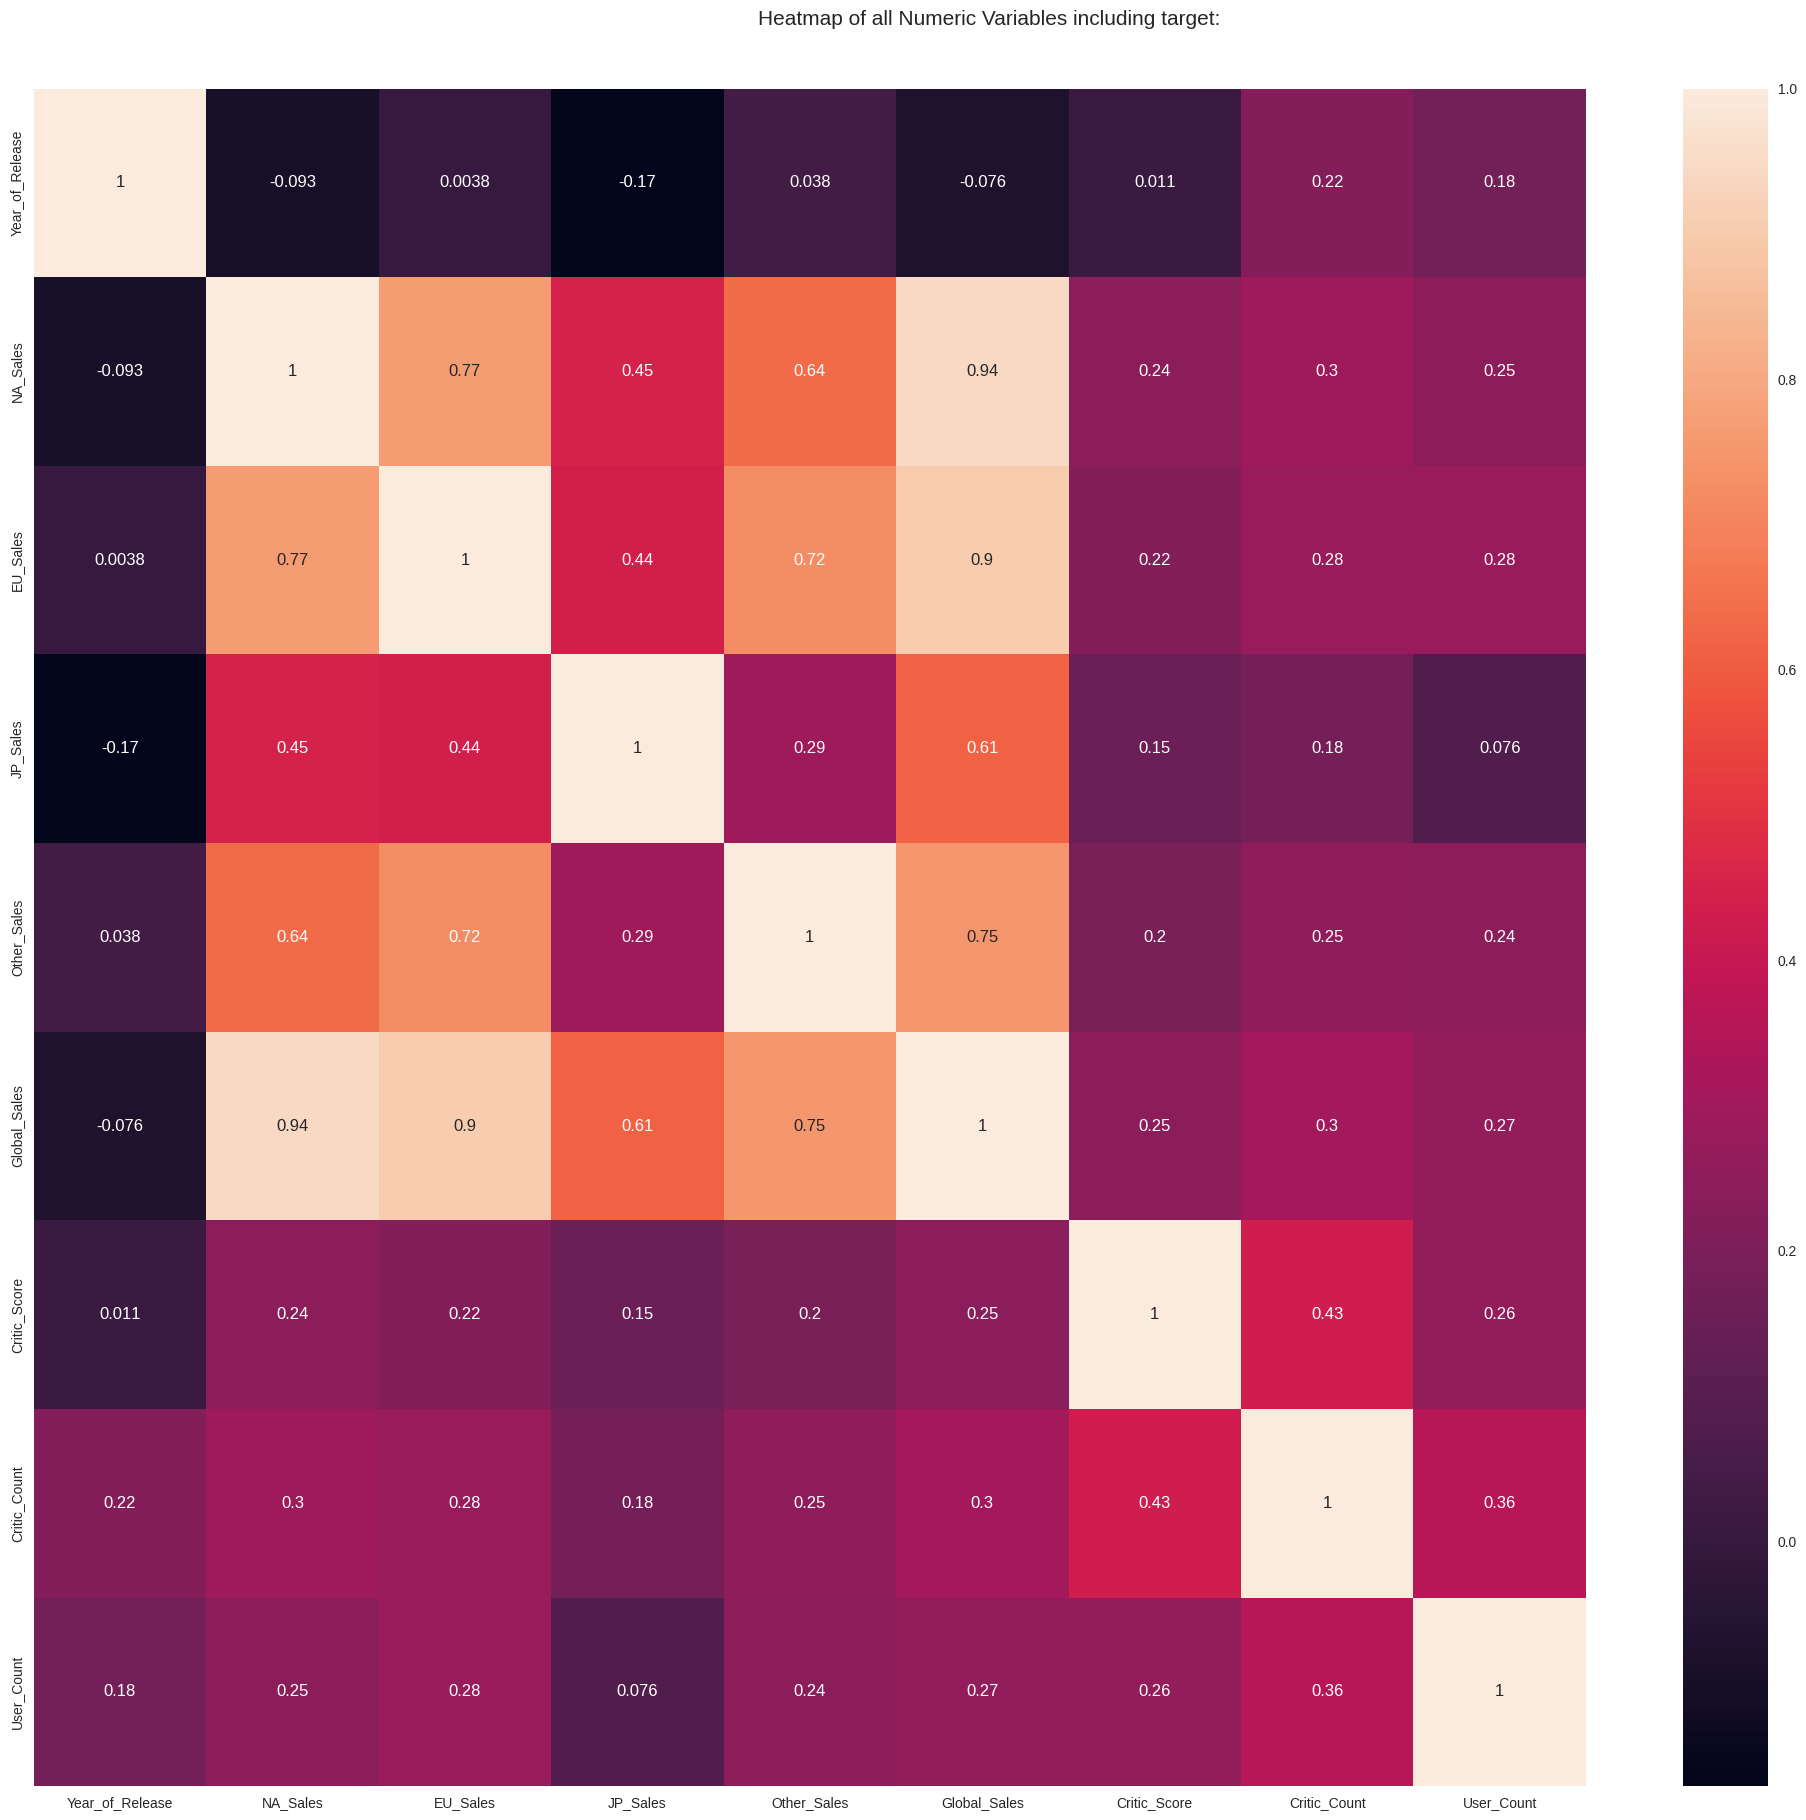

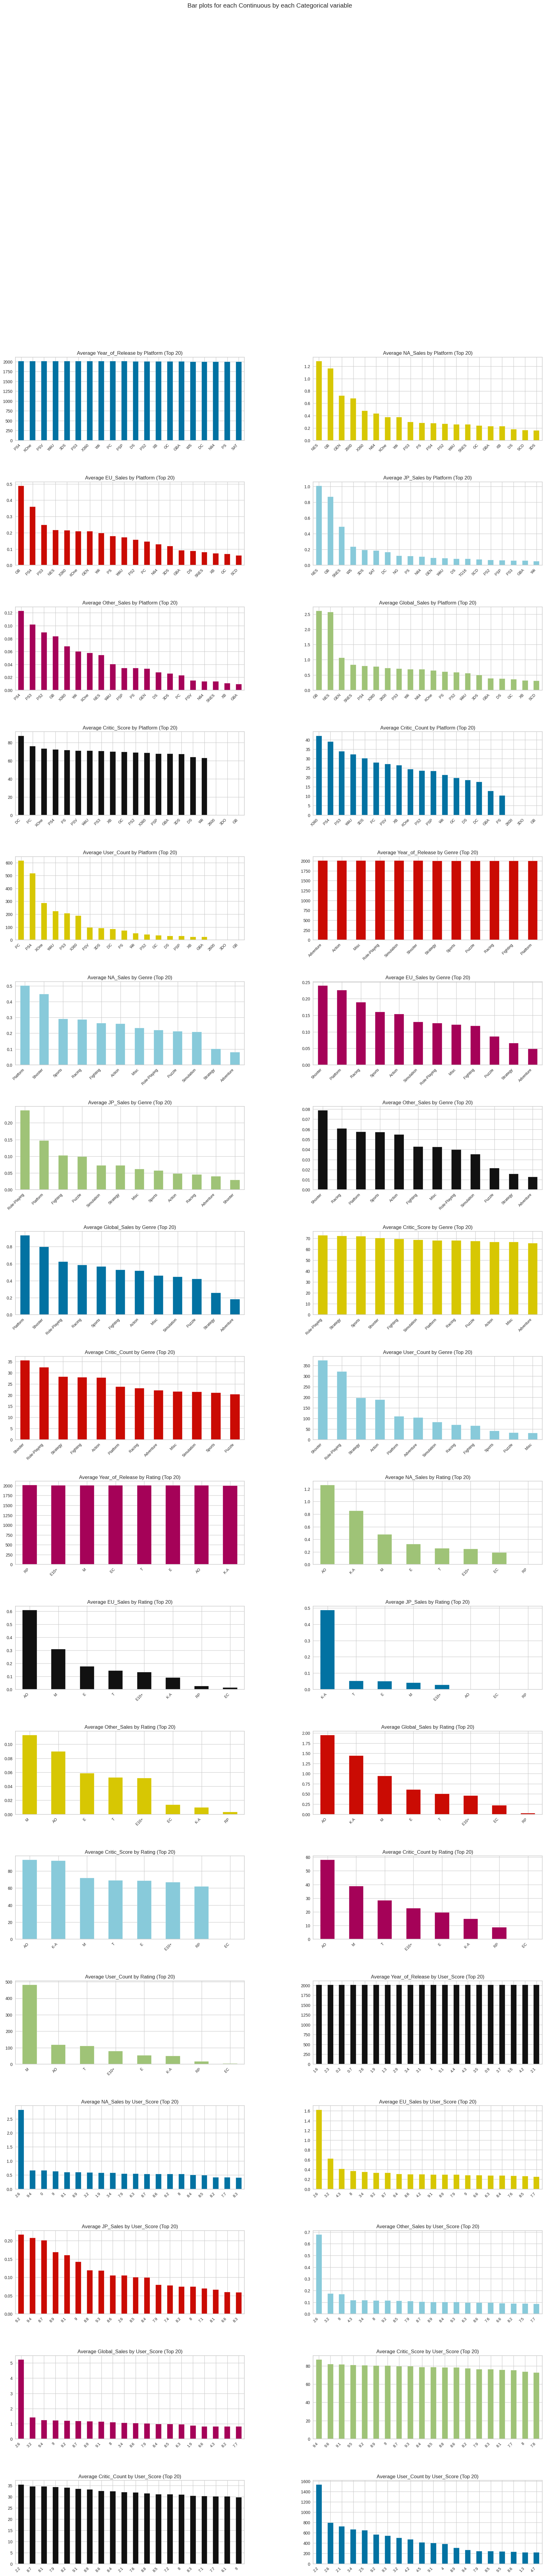

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

Could not draw wordcloud plot for Name. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Could not draw wordcloud plot for Developer. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Could not draw wordcloud plot for Publisher. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http:/

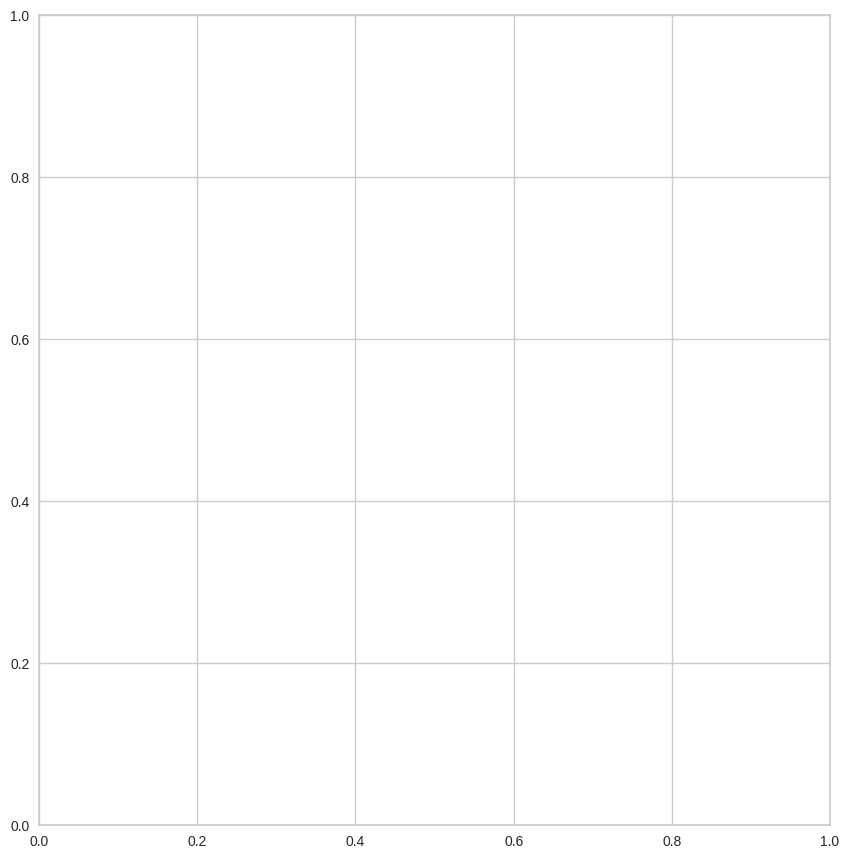

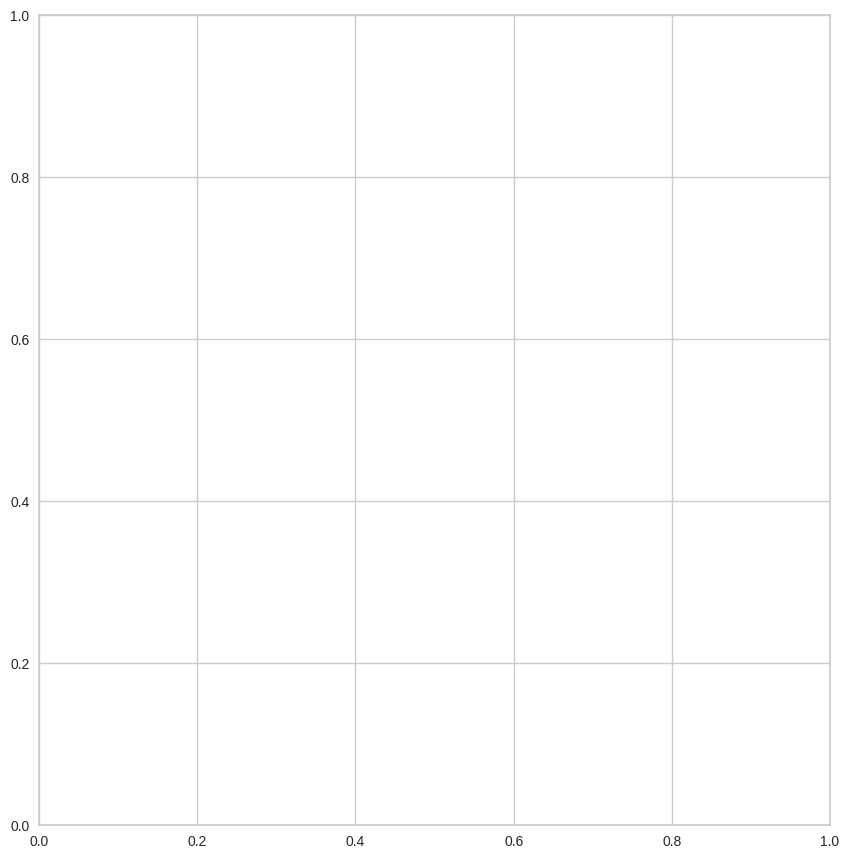

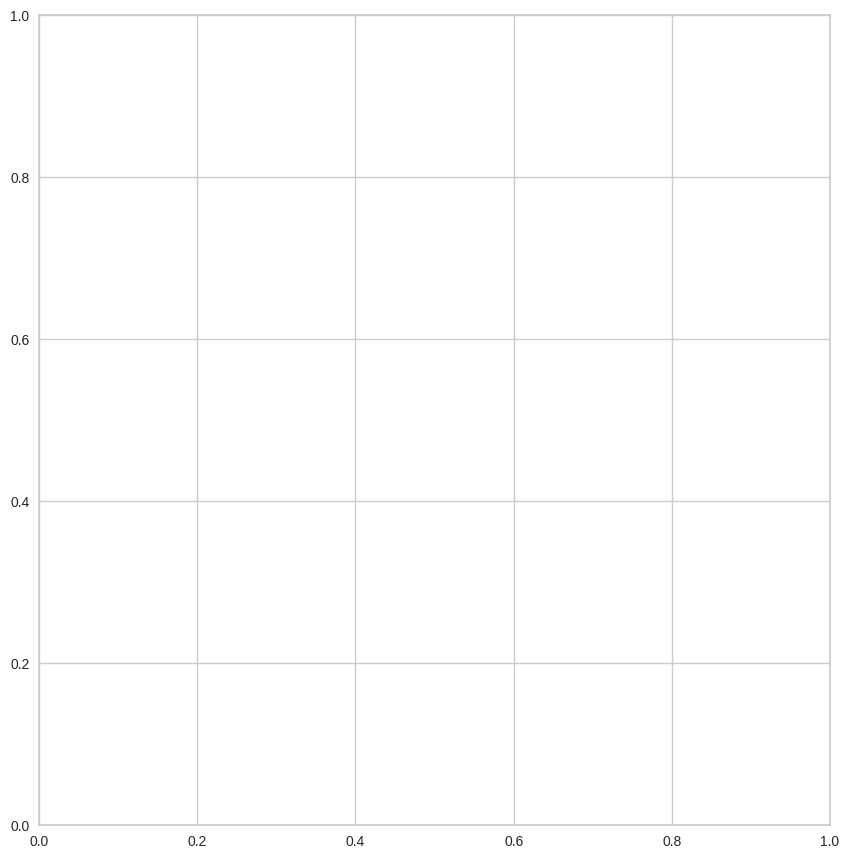

In [ ]:
# AutoViz visualization
AV = AutoViz_Class()
auto_viz = AV.AutoViz('Video_Games_Sales_as_at_22_Dec_2016.csv')

# Prepare Data

In [ ]:
# Drop columns with many missing values or irrelevant
df1 = df.drop(columns=["Name","Year_of_Release","NA_Sales","EU_Sales","JP_Sales","Other_Sales"])
# Fill missing values
df1 = df1.dropna()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6943 entries, 0 to 16706
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Platform      6943 non-null   object 
 1   Genre         6943 non-null   object 
 2   Publisher     6943 non-null   object 
 3   Global_Sales  6943 non-null   float64
 4   Critic_Score  6943 non-null   float64
 5   Critic_Count  6943 non-null   float64
 6   User_Score    6943 non-null   object 
 7   User_Count    6943 non-null   float64
 8   Developer     6943 non-null   object 
 9   Rating        6943 non-null   object 
dtypes: float64(4), object(6)
memory usage: 596.7+ KB


In [ ]:
df1.value_counts("Genre")


,count
Genre,
Action,1663
Sports,965
Shooter,882
Role-Playing,718
Racing,591
Platform,406
Misc,394
Fighting,381
Simulation,301


In [ ]:
rating_map = {
    'K-A': 1,
    'E': 2,
    'E10+': 3,
    'T': 4,
    'M': 5,
    'AO': 6,
    'RP': 0
}

df1['Rating_Encoded'] = df1['Rating'].map(rating_map)

In [ ]:
df2 = df1.drop(columns=["Rating"])

In [ ]:
bins = [0, 0.5, 1, 5, 20, 100]
labels = [
    '0-500K', '500K-1M', '1-5M', '5-20M', '20M+'
]



df2['Sales_Category'] = pd.cut(df2['Global_Sales'], bins=bins, labels=labels, right=False)


print(df2['Sales_Category'].value_counts())

Sales_Category
0-500K     4446
1-5M       1184
500K-1M    1169
5-20M       131
20M+         13
Name: count, dtype: int64


In [ ]:
df3 = df2.drop(columns=["Global_Sales"])
from sklearn.preprocessing import OneHotEncoder


In [ ]:
genre_map = {
    'Action': 'Action-Oriented',
    'Shooter': 'Action-Oriented',
    'Fighting': 'Action-Oriented',
    'Sports': 'Sports/Racing',
    'Racing': 'Sports/Racing',
    'Role-Playing': 'Adventure/RPG',
    'Adventure': 'Adventure/RPG',
    'Strategy': 'Strategy/Sim',
    'Simulation': 'Strategy/Sim',
    'Puzzle': 'Strategy/Sim',
    'Platform': 'Casual/Misc',
    'Misc': 'Casual/Misc'
}

# Step 2: Map the genre to the new categories
df3['genre_grouped'] = df3['Genre'].map(genre_map)
df4 = df3.drop(columns=["Genre"])



In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6943 entries, 0 to 16706
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Platform        6943 non-null   object  
 1   Publisher       6943 non-null   object  
 2   Critic_Score    6943 non-null   float64 
 3   Critic_Count    6943 non-null   float64 
 4   User_Score      6943 non-null   object  
 5   User_Count      6943 non-null   float64 
 6   Developer       6943 non-null   object  
 7   Rating_Encoded  6943 non-null   int64   
 8   Sales_Category  6943 non-null   category
 9   genre_grouped   6943 non-null   object  
dtypes: category(1), float64(3), int64(1), object(5)
memory usage: 549.4+ KB


In [ ]:
from pycaret.classification import *

# Set up the PyCaret environment with 'genre_grouped' as the target column
# Assuming df3 is your DataFrame and 'genre_grouped' is the encoded column
clf1 = setup(data=df4, target='genre_grouped', session_id=123)

,Description,Value
0,Session id,123
1,Target,genre_grouped
2,Target type,Multiclass
3,Target mapping,"Action-Oriented: 0, Adventure/RPG: 1, Casual/Misc: 2, Sports/Racing: 3, Strategy/Sim: 4"
4,Original data shape,"(6943, 10)"
5,Transformed data shape,"(6943, 30)"
6,Transformed train set shape,"(4860, 30)"
7,Transformed test set shape,"(2083, 30)"
8,Numeric features,4
9,Categorical features,5


# Model

In [ ]:


best_model = compare_models(include=['rf'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.6681,0.8802,0.6681,0.6598,0.6590,0.5348,0.5370,0.7440


Processing:   0%|          | 0/9 [00:00<?, ?it/s]

# Evaluate

In [ ]:
# Create and evaluate a Random Forest model
rf_model = create_model('rf')
evaluate_model(rf_model)
predict_model(rf_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7078,0.8874,0.7078,0.6955,0.6974,0.5895,0.5917
1,0.6626,0.8733,0.6626,0.6551,0.6514,0.5211,0.5249
2,0.6584,0.8850,0.6584,0.6365,0.6420,0.5164,0.5196
3,0.6646,0.8757,0.6646,0.6538,0.6570,0.5320,0.5331
4,0.6626,0.8820,0.6626,0.6551,0.6544,0.5285,0.5302
5,0.6440,0.8729,0.6440,0.6388,0.6386,0.5040,0.5050
6,0.6502,0.8783,0.6502,0.6459,0.6425,0.5078,0.5100
7,0.6790,0.8761,0.6790,0.6733,0.6724,0.5529,0.5543
8,0.6708,0.8917,0.6708,0.6677,0.6575,0.5361,0.5406


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.6726,0.8772,0.6726,0.6665,0.6669,0.5431,0.5443


,Platform,Publisher,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating_Encoded,Sales_Category,genre_grouped,prediction_label,prediction_score
5191,GBA,Nintendo,72.0,7.0,9.3,18.0,Pax Softonica,2,0-500K,Action-Oriented,Sports/Racing,0.36
14805,XB,Take-Two Interactive,83.0,8.0,8.6,5.0,"Kush Games, Visual Concepts",2,0-500K,Sports/Racing,Sports/Racing,0.86
2306,PS3,THQ,74.0,44.0,7.4,10.0,Rainbow Studios,2,500K-1M,Sports/Racing,Sports/Racing,0.73
11236,X360,Vivendi Games,66.0,43.0,7.1,16.0,"TimeGate Studios, Day 1 Studios",5,0-500K,Action-Oriented,Action-Oriented,0.55
16532,PC,Konami Digital Entertainment,78.0,8.0,6.9,49.0,Konami,2,0-500K,Sports/Racing,Sports/Racing,0.73
...,...,...,...,...,...,...,...,...,...,...,...,...
4082,PSP,MTV Games,79.0,50.0,8.6,31.0,"Harmonix Music Systems, Backbone Entertainment",4,0-500K,Casual/Misc,Adventure/RPG,0.27
4706,WiiU,Activision,81.0,31.0,6.9,228.0,Treyarch,5,0-500K,Action-Oriented,Action-Oriented,0.92
10035,PS2,Sega,69.0,12.0,8.1,20.0,Neverland,4,0-500K,Adventure/RPG,Adventure/RPG,0.53
12335,Wii,Sega,45.0,38.0,6.9,11.0,High Voltage Software,4,0-500K,Action-Oriented,Action-Oriented,0.77


# Tune, Best Model

In [ ]:
tuned_rf = tune_model(rf_model)
final_rf = finalize_model(tuned_rf)
save_model(final_rf, 'final_rf_model')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8730,0.8659,0.7083,0.9444,0.8095,0.7172,0.7339
1,0.8254,0.7890,0.7083,0.8095,0.7556,0.6207,0.6240
2,0.7778,0.8894,0.5000,0.8571,0.6316,0.4878,0.5241
3,0.8226,0.8534,0.6087,0.8750,0.7179,0.5945,0.6154
4,0.7419,0.7440,0.3750,0.9000,0.5294,0.3907,0.4618
5,0.7419,0.8317,0.5000,0.7500,0.6000,0.4206,0.4394
6,0.8710,0.9194,0.7917,0.8636,0.8261,0.7238,0.7256
7,0.8065,0.7939,0.6667,0.8000,0.7273,0.5792,0.5850
8,0.7097,0.7769,0.5417,0.6500,0.5909,0.3688,0.3725


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['pclass', 'age', 'sibsp', 'parch',
                                              'fare'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=['sex...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None,

# References

- Titanic dataset from seaborn
- PyCaret Documentation: https://pycaret.gitbook.io/docs/
- AutoViz GitHub: https://github.com/AutoViML/AutoViz